# Задание: Распознавание рукописных цифр (MNIST) методом fine-tuning ResNet50

Вместо обучения свёрточной сети с нуля используется **fine-tuning** — дообучение готовой архитектуры **ResNet50**, предварительно обученной на ImageNet. Это современный и более точный подход к задачам компьютерного зрения.

**Структура модели:**
- предобученная база ResNet50 (десятки свёрточных слоёв, BatchNormalization, pooling — внутри неё)
- собственная «голова»: GlobalAveragePooling → BatchNorm → Dense → Dropout → Dense(10, softmax)

**Гиперпараметры:** функция ошибки — категориальная кроссэнтропия, оптимизатор — Adam (lr = 1e-3 на 1-м этапе, 1e-5 на 2-м), размер батча — 128, общее число эпох — 15.

**Стратегия fine-tuning (двухэтапная):**
1. *Этап 1.* База ResNet50 заморожена, обучается только голова. Это быстро адаптирует выход под 10 классов MNIST.
2. *Этап 2.* Размораживаются верхние блоки ResNet50, обучение продолжается с очень маленьким `lr`, чтобы аккуратно подстроить признаки под рукописные цифры.


In [1]:
# загрузка датасета MNIST
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [2]:
# Подключение утилит для to_categorical
from tensorflow.keras import utils

# Подключение библиотеки для работы с массивами
import numpy as np

# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt

# Подключение библиотеки для генерации случайных чисел
import random

# Подключение класса для работы с изображением
from PIL import Image

# Вывод изображений в ноутбуке, а не в консоли или файле
%matplotlib inline

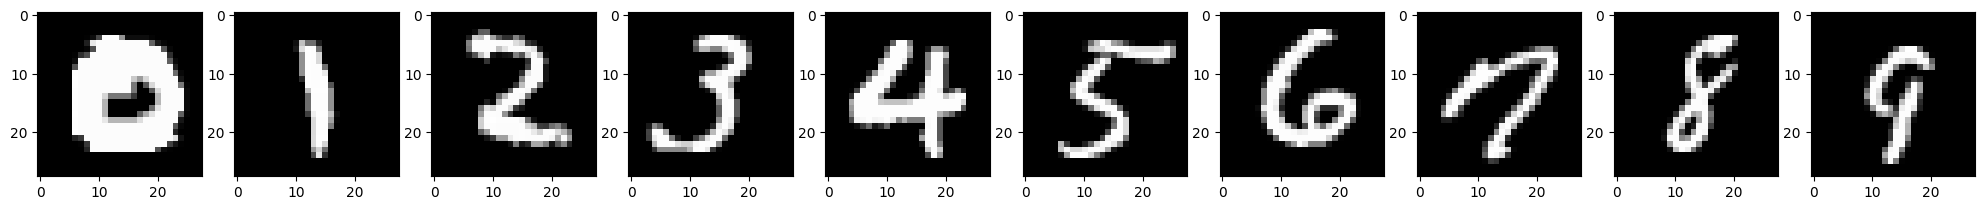

In [3]:
# вывод изображений каждого класса для ознакомления с датасетом
fig, axs = plt.subplots(1, 10, figsize=(25,3)) # создаем полотно для 10 графиков с размером 25 на 3
for i in range(10):
    label_indexes = np.where(y_train == i)[0] # получаем список из индексов положений класса i в y_train
    index = random.choice(label_indexes) # выбирает случайный индекс из списка созданного выше
    img = x_train[index] # выбираем из x_train нужное положение
    axs[i].imshow(Image.fromarray(img), cmap='gray') # выводим изображение

plt.show()

In [4]:
# Подготовка данных под fine-tuning ResNet50
# ResNet50 ждёт на входе 3-канальные изображения. MNIST — одноканальный.
# Чтобы не раздувать numpy-массив, дублирование каналов и ресайз сделаем
# прямо ВНУТРИ модели (слоями Keras). Здесь — только reshape и OHE.

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test  = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')

y_train = utils.to_categorical(y_train, 10)
y_test  = utils.to_categorical(y_test, 10)

print('x_train:', x_train.shape)
print('x_test :', x_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


x_train: (60000, 28, 28, 1)
x_test : (10000, 28, 28, 1)
y_train: (60000, 10)
y_test : (10000, 10)


# Ваше решение: fine-tuning ResNet50


In [5]:
# ===== Импорты =====
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Concatenate, Resizing, Lambda,
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam

# ===== Размер, до которого ресайзим картинки =====
# ResNet50 формально требует минимум 32x32, но при таком размере признаки извлекаются плохо.
# Берём 64x64 — компромисс между качеством признаков и потреблением памяти.
IMG_SIZE = 64

# ===== Входной тензор и предобработка прямо в модели =====
inputs = Input(shape=(28, 28, 1))                     # оригинал MNIST
x = Concatenate(axis=-1)([inputs, inputs, inputs])    # 1 канал -> 3 канала (повтор)
x = Resizing(IMG_SIZE, IMG_SIZE)(x)                   # 28x28 -> 64x64
x = Lambda(preprocess_input)(x)                       # нормализация под ImageNet

# ===== Загружаем предобученную базу ResNet50 =====
# include_top=False — без её родного классификатора на 1000 классов ImageNet,
# свою голову на 10 классов поставим сами ниже.
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

# На 1-м этапе вся база заморожена — обучаться будет только голова
base_model.trainable = False

x = base_model(x, training=False)        # training=False важно для BatchNorm в замороженной базе
x = GlobalAveragePooling2D()(x)          # свёртываем карту признаков в вектор
x = BatchNormalization()(x)              # нормализация
x = Dense(128, activation='relu')(x)     # полносвязный слой
x = Dropout(0.3)(x)                      # регуляризация
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28, 28, 3) │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 64, 64, 3) │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64, 64, 3) │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 2, 2,      │ 23,587,712 │ lambda[0][0]      │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      1,290 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,859,466 (91.02 MB)

 Trainable params: 267,658 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [6]:
# ===== ЭТАП 1: обучаем только голову, база заморожена =====
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy'],
)

EPOCHS_STAGE1 = 5     # быстро адаптируем голову
EPOCHS_STAGE2 = 10    # затем тонко донастраиваем верхние блоки базы
# Итого 15 эпох — как в задании

print('=' * 60)
print('ЭТАП 1: обучение головы (база ResNet50 заморожена)')
print('=' * 60)
history1 = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=EPOCHS_STAGE1,
    validation_data=(x_test, y_test),
    verbose=1,
)

# ===== ЭТАП 2: размораживаем верхние блоки ResNet50 =====
# Размораживать ВСЁ для маленького датасета как MNIST рискованно — переобучимся.
# Поэтому размораживаем только верхнюю часть сети (примерно последние 30 слоёв).
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Перекомпилируем с очень маленьким lr (1e-5), чтобы не «сломать» предобученные веса
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy'],
)

print()
print('=' * 60)
print('ЭТАП 2: fine-tuning верхних блоков ResNet50 (lr = 1e-5)')
print('=' * 60)
history2 = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=EPOCHS_STAGE2,
    validation_data=(x_test, y_test),
    verbose=1,
)

# Склеиваем истории двух этапов в одну
history = {
    'accuracy':     history1.history['accuracy']     + history2.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'],
    'loss':         history1.history['loss']         + history2.history['loss'],
    'val_loss':     history1.history['val_loss']     + history2.history['val_loss'],
}


ЭТАП 1: обучение головы (база ResNet50 заморожена)
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.9267 - loss: 0.2381 - val_accuracy: 0.9672 - val_loss: 0.1035
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9652 - loss: 0.1056 - val_accuracy: 0.9713 - val_loss: 0.0921
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9751 - loss: 0.0760 - val_accuracy: 0.9761 - val_loss: 0.0872
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9787 - loss: 0.0648 - val_accuracy: 0.9756 - val_loss: 0.0946
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9814 - loss: 0.0561 - val_accuracy: 0.9753 - val_loss: 0.0900

ЭТАП 2: fine-tuning верхних блоков ResNet50 (lr = 1e-5)
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 59s 82ms/step - accuracy: 0.9316 - loss: 0.2330 - val_accuracy: 0.9708 - val_loss: 0.0939
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9761 - loss: 0.0727 - val_accuracy: 0.9772 - val_

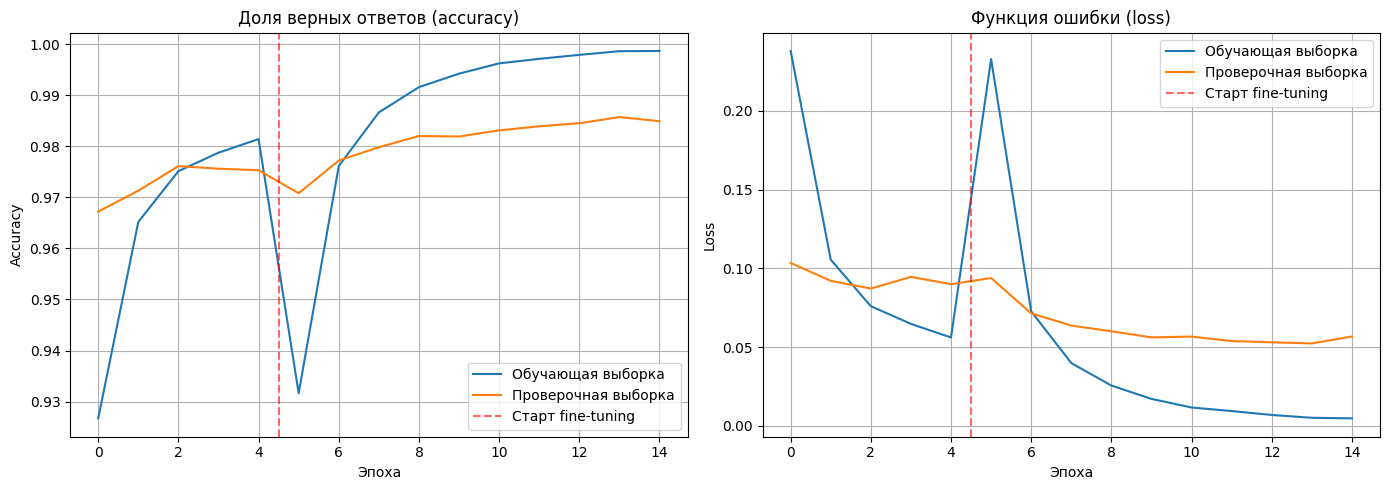

Итоговая точность на обучающей выборке:   99.87%
Итоговая точность на проверочной выборке: 98.49%


In [7]:
# ========== График обучения ==========
# Доли верных ответов на обучающей и проверочной выборках.
# Красная пунктирная линия — момент перехода с этапа 1 (заморозка) на этап 2 (fine-tuning).

plt.figure(figsize=(14, 5))

# График accuracy
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'],     label='Обучающая выборка')
plt.plot(history['val_accuracy'], label='Проверочная выборка')
plt.axvline(x=EPOCHS_STAGE1 - 0.5, color='red', linestyle='--', alpha=0.6, label='Старт fine-tuning')
plt.title('Доля верных ответов (accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'],     label='Обучающая выборка')
plt.plot(history['val_loss'], label='Проверочная выборка')
plt.axvline(x=EPOCHS_STAGE1 - 0.5, color='red', linestyle='--', alpha=0.6, label='Старт fine-tuning')
plt.title('Функция ошибки (loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Итоговая точность на обучающей выборке:   {history['accuracy'][-1]*100:.2f}%")
print(f"Итоговая точность на проверочной выборке: {history['val_accuracy'][-1]*100:.2f}%")


## Матрица ошибок (Confusion Matrix)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


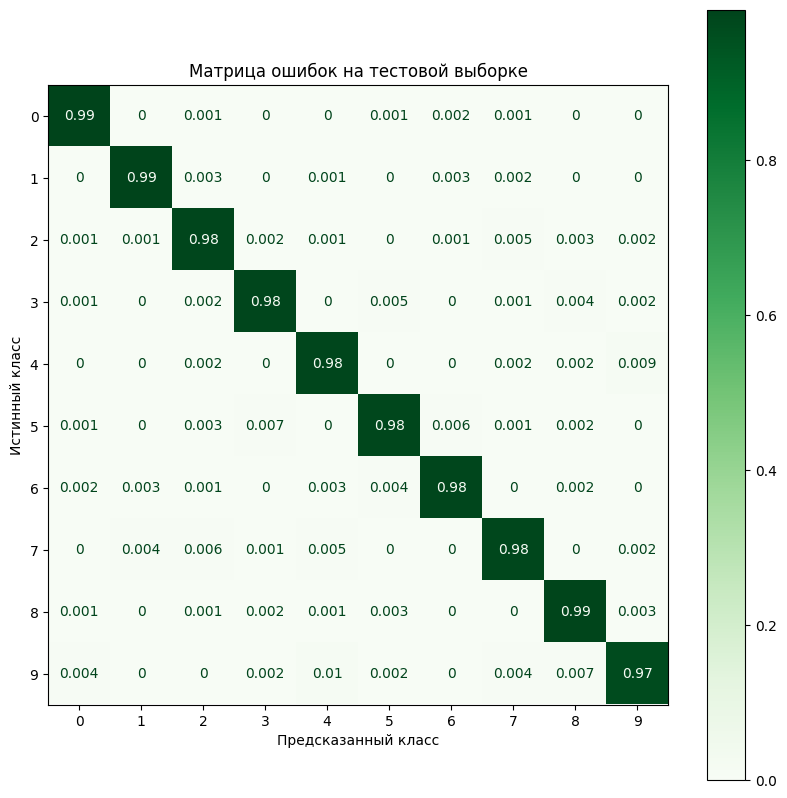


Общая точность на тестовой выборке: 0.9849 (98.49%)


In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Получаем предсказания модели на тестовой выборке
y_pred = model.predict(x_test)

# Преобразуем OHE в номера классов
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Строим матрицу ошибок (нормализованную)
cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
cm = np.round(cm, 3)

# Отображаем матрицу ошибок
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Greens', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Вывод общей точности
accuracy = np.mean(y_pred_classes == y_true_classes)
print(f'\nОбщая точность на тестовой выборке: {accuracy:.4f} ({accuracy*100:.2f}%)')